In [58]:
import os, sys
from copy import deepcopy
from json import load, dump
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
fontsize = 16
plt.style.use([hep.style.ROOT, {'font.size': fontsize}])
sys.path.append("/work/mmarcheg/BTVNanoCommissioning")
from parameters import AK8Taggers

In [51]:
folders = {
    "2016_PreVFP" : "/work/mmarcheg/BTVNanoCommissioning/output/fit/approval/2016_PreVFP/fit_tau21p30_all_breakdown",
    "2016_PostVFP" : "/work/mmarcheg/BTVNanoCommissioning/output/fit/approval/2016_PostVFP/fit_tau21p30_all_breakdown",
    "2017" : "/work/mmarcheg/BTVNanoCommissioning/output/fit/approval/2017/fit_tau21p30_all_breakdown_v01",
    "2018" : "/work/mmarcheg/BTVNanoCommissioning/output/fit/approval/2018/fit_tau21p30_all_breakdown_v04",
}
files_results = list(filter(lambda x : 'sf_results' in x, os.listdir()))
results = {}
for year in folders.keys():
    for file in files_results:
        if year in file:
            results[year] = file
results

{'2016_PreVFP': 'sf_results_2016_PreVFP.csv',
 '2016_PostVFP': 'sf_results_2016_PostVFP.csv',
 '2017': 'sf_results_2017.csv',
 '2018': 'sf_results_2018.csv'}

In [52]:
missing_fits = {}
final_results = {}
for year, folder in folders.items():
    final_results[year] = {}
    missing_fits[year] = []
    df_results = pd.read_csv(results[year])
    for tagger in AK8Taggers:
        final_results[year][tagger] = {}
        for pt in ["450to500", "500to600", "600toInf"]:
            final_results[year][tagger][pt] = {}
            for wp in ["L", "M", "H"]:
                sfdata = df_results[(df_results.tagger == tagger)&\
                                    (df_results.pt == pt)&\
                                    (df_results.wp == wp)]
                model_name = f"msd40{tagger}{wp}wp_Pt-{pt}"
                fitdir = os.path.join(folder, "fitdir", model_name)
                file_breakdown = os.path.join(fitdir, "breakdown.json")
                if os.path.exists(file_breakdown):
                    d = load(open(file_breakdown, 'r'))
                    final_results[year][tagger][pt][wp] = deepcopy(d)
                    final_results[year][tagger][pt][wp].update({
                        "tau21_uncertainty" : {},
                        "tau21_uncertainty_max" : {},
                        "reweighting_uncertainty" : {},
                    })
                    final_results[year][tagger][pt][wp]["tau21_uncertainty"]['high'] = sfdata.tau21_uncertainty.values[0]
                    final_results[year][tagger][pt][wp]["tau21_uncertainty"]['low'] = sfdata.tau21_uncertainty.values[0]
                    final_results[year][tagger][pt][wp]["tau21_uncertainty_max"]['high'] = sfdata.tau21_uncertainty_max.values[0]
                    final_results[year][tagger][pt][wp]["tau21_uncertainty_max"]['low'] = sfdata.tau21_uncertainty_max.values[0]
                    final_results[year][tagger][pt][wp]["reweighting_uncertainty"]['high'] = sfdata.reweighting_uncertainty.values[0]
                    final_results[year][tagger][pt][wp]["reweighting_uncertainty"]['low'] = sfdata.reweighting_uncertainty.values[0]
                else:
                    missing_fits[year].append(model_name)
                    continue
                
    #models = os.listdir(fitdir)
    #for model_name in models:
        
missing_fits

{'2016_PreVFP': ['msd40btagDDBvLV2Lwp_Pt-450to500',
  'msd40btagDDBvLV2Mwp_Pt-450to500',
  'msd40btagDDBvLV2Lwp_Pt-500to600',
  'msd40btagDDBvLV2Lwp_Pt-600toInf',
  'msd40btagDDCvLV2Lwp_Pt-450to500',
  'msd40deepTagMD_ZHbbvsQCDHwp_Pt-450to500',
  'msd40btagHbbLwp_Pt-450to500',
  'msd40btagHbbMwp_Pt-450to500',
  'msd40btagHbbLwp_Pt-500to600',
  'msd40btagHbbMwp_Pt-500to600',
  'msd40btagHbbLwp_Pt-600toInf'],
 '2016_PostVFP': ['msd40btagHbbLwp_Pt-450to500',
  'msd40btagHbbMwp_Pt-450to500',
  'msd40btagHbbLwp_Pt-500to600',
  'msd40btagHbbLwp_Pt-600toInf'],
 '2017': ['msd40btagHbbLwp_Pt-450to500',
  'msd40btagHbbLwp_Pt-500to600',
  'msd40btagHbbLwp_Pt-600toInf'],
 '2018': ['msd40btagDDBvLV2Lwp_Pt-450to500',
  'msd40deepTagMD_ZHbbvsQCDLwp_Pt-450to500',
  'msd40btagHbbLwp_Pt-450to500',
  'msd40btagHbbLwp_Pt-500to600',
  'msd40btagHbbLwp_Pt-600toInf']}

In [53]:
print("Missing fits:")
for year, fits in missing_fits.items():
    print(year, len(fits))

Missing fits:
2016_PreVFP 11
2016_PostVFP 4
2017 3
2018 5


In [60]:
dump(final_results, open("final_results.json", 'w'), indent=4)

In [55]:
final_results["2018"]["particleNetMD_Xbb_QCD"]["450to500"]["H"]

{'JER': {'high': 0.0, 'low': 0.009818026015422773},
 'all': {'high': 0.054237213241687954,
  'central': 1.0567500591278076,
  'low': 0.04534332738511426},
 'psWeight_isr': {'high': 0.0009563516991728641, 'low': 0.0004296211895813167},
 'lumi': {'high': 0.003762124327100139, 'low': 0.0},
 'psWeight_fsr': {'high': 0.0, 'low': 0.0},
 'QCDFlvCompos': {'high': 0.002555052031923937, 'low': 0.00045144345558398134},
 'stat': {'high': 0.02507170174627804, 'low': 0.030837424766930743},
 'JES_Total': {'high': 0.035027126227535905, 'low': 0.015930196055824537},
 'frac_l': {'high': 0.02051789086212838, 'low': 0.014409021044208348},
 'frac_bb': {'high': 0.020799179164828836, 'low': 0.020402005552130252},
 'pileup': {'high': 0.0028171288136528408, 'low': 0.004181248236826722},
 'frac_cc': {'high': 0.02060781868455268, 'low': 0.015863314349048807},
 'tau21_uncertainty': {'high': 0.0380716312573789, 'low': 0.0380716312573789},
 'tau21_uncertainty_max': {'high': 0.1060554896514979,
  'low': 0.1060554896

/tmp/ipykernel_25692/3413470311.py:18: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 1, figsize=[8,8])


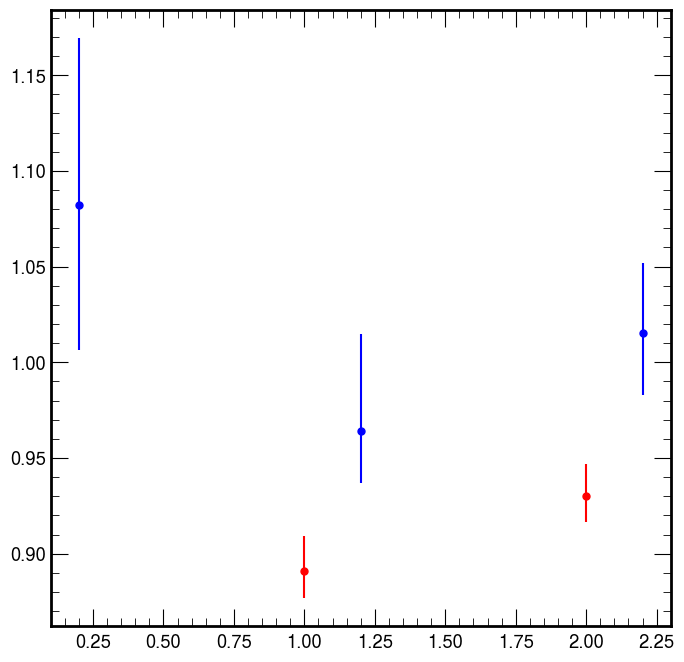

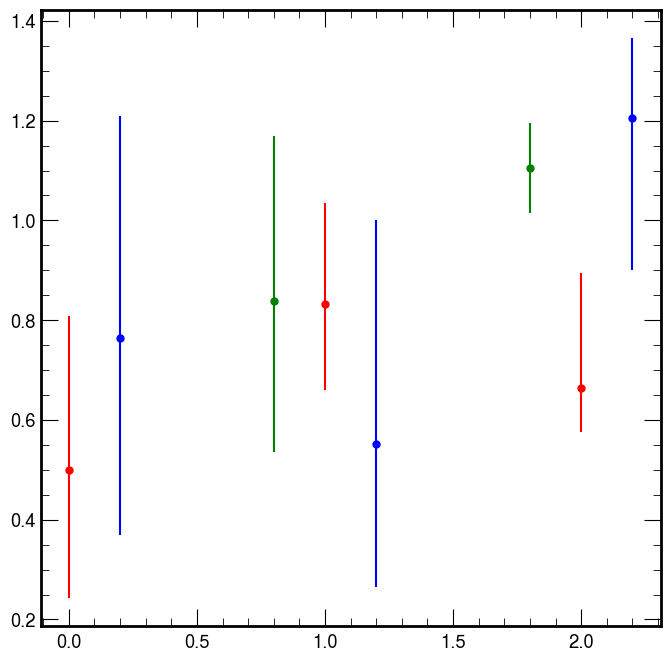

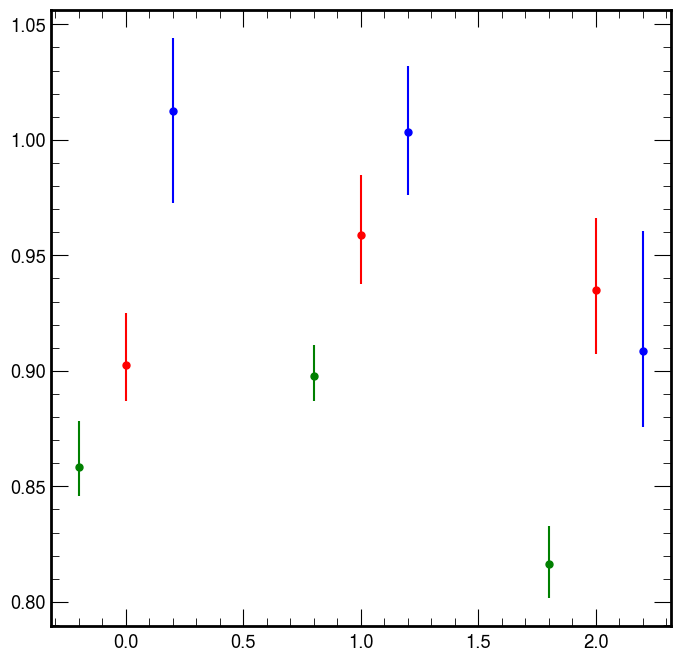

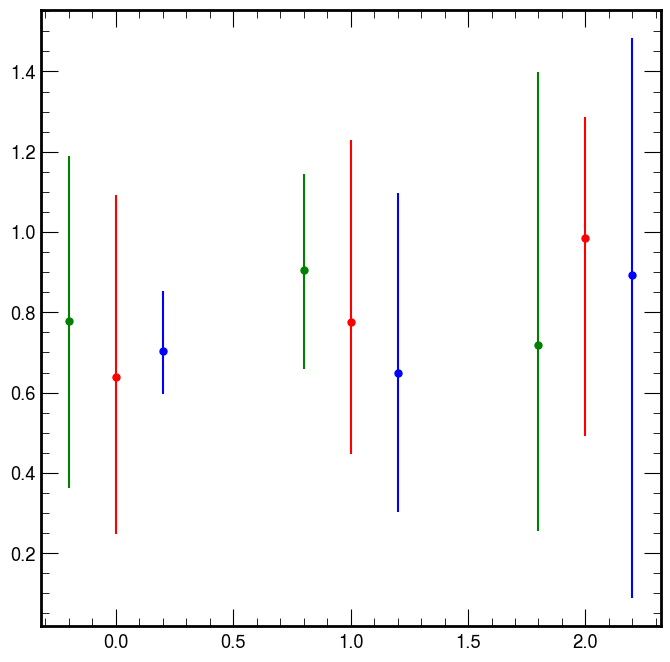

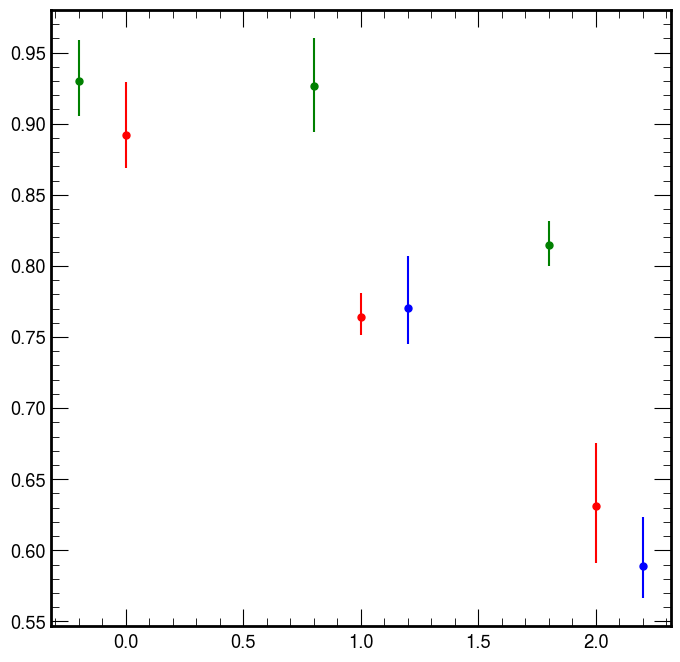

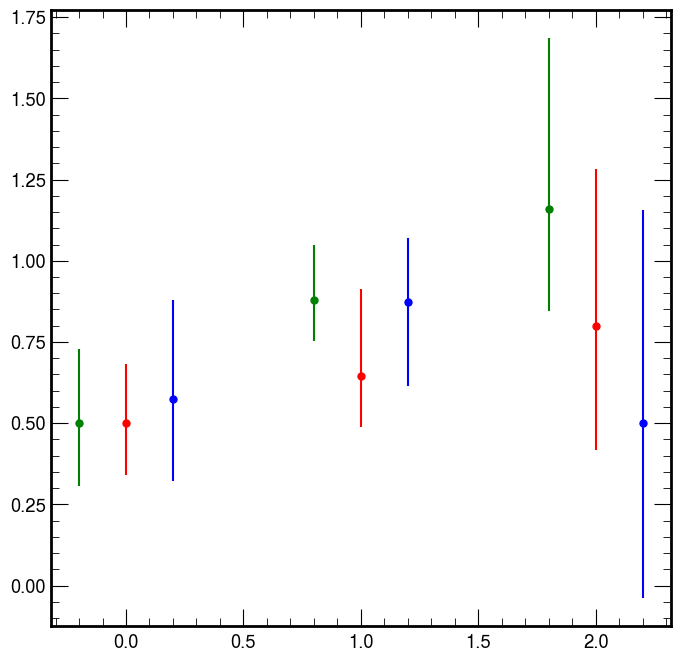

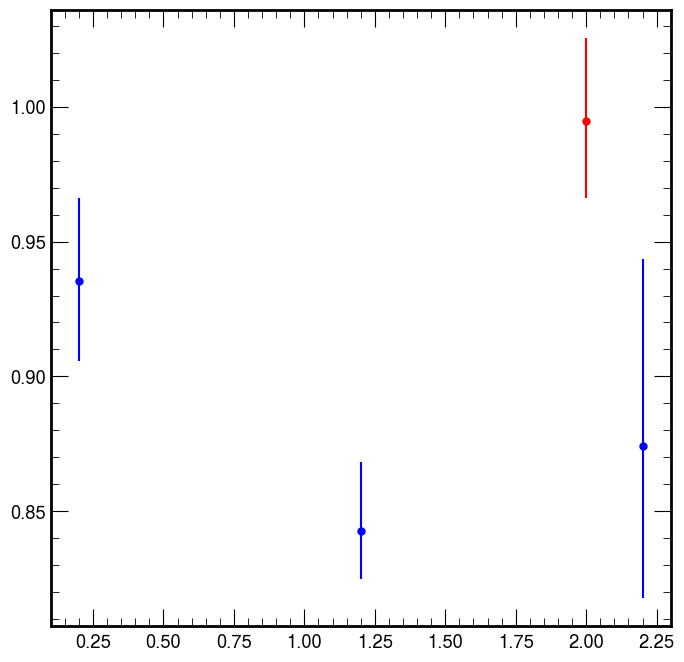

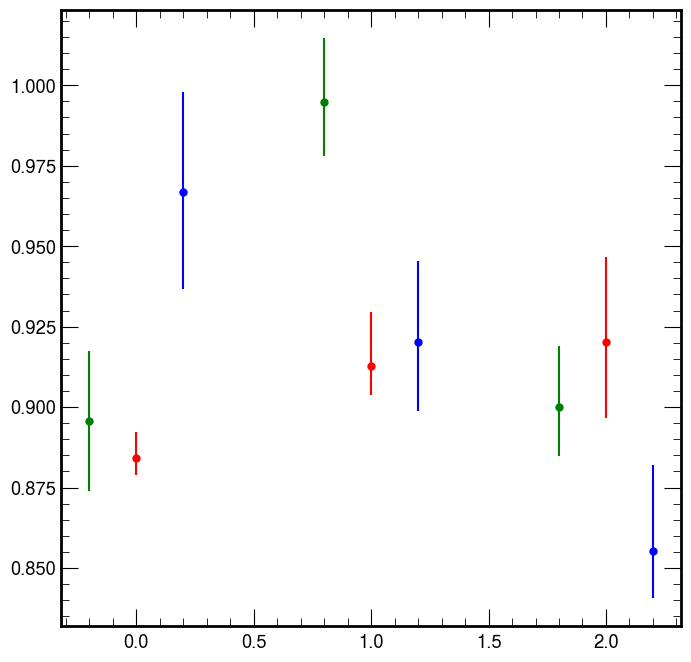

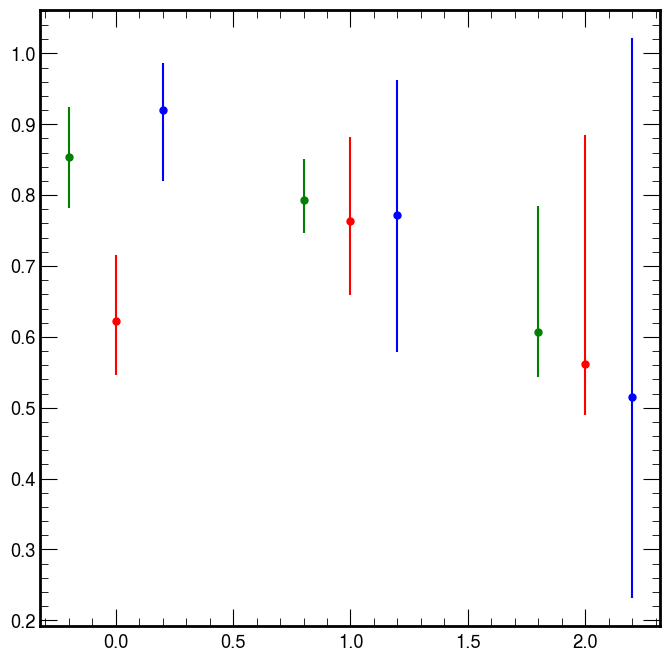

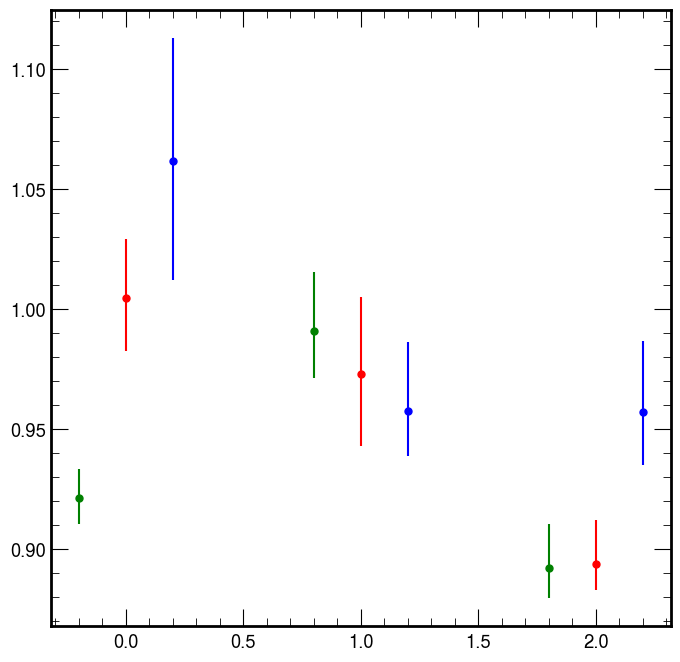

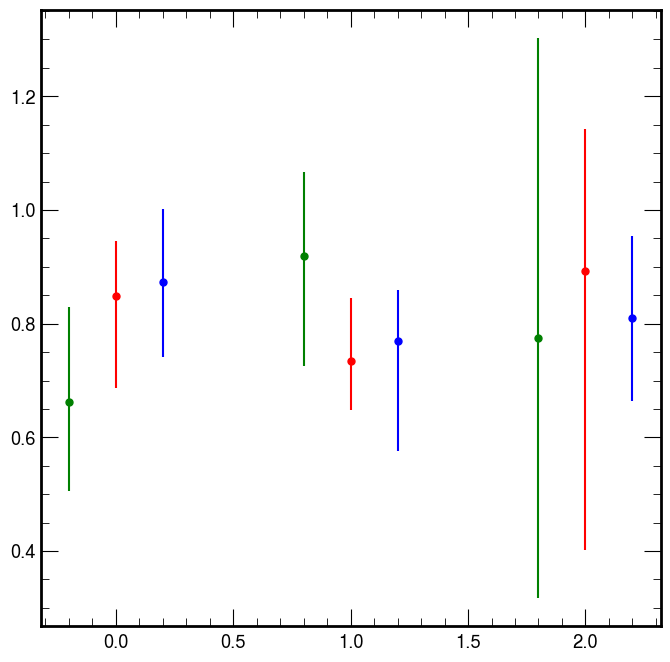

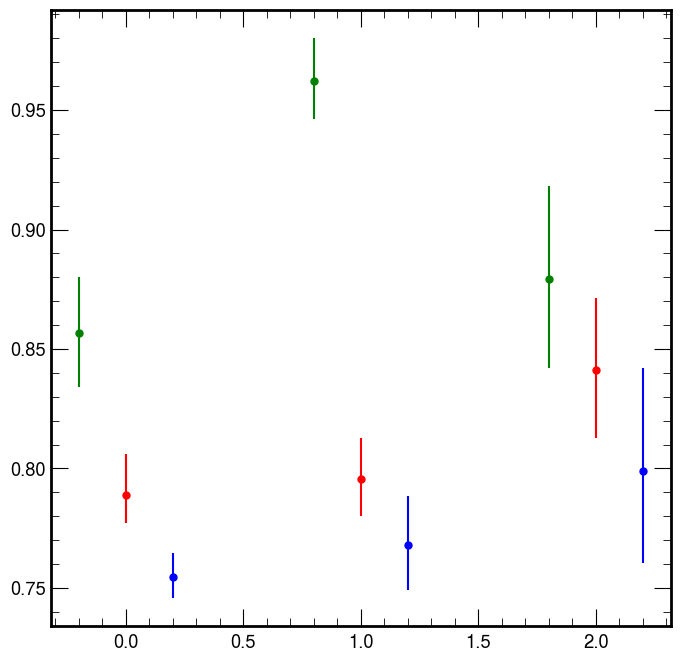

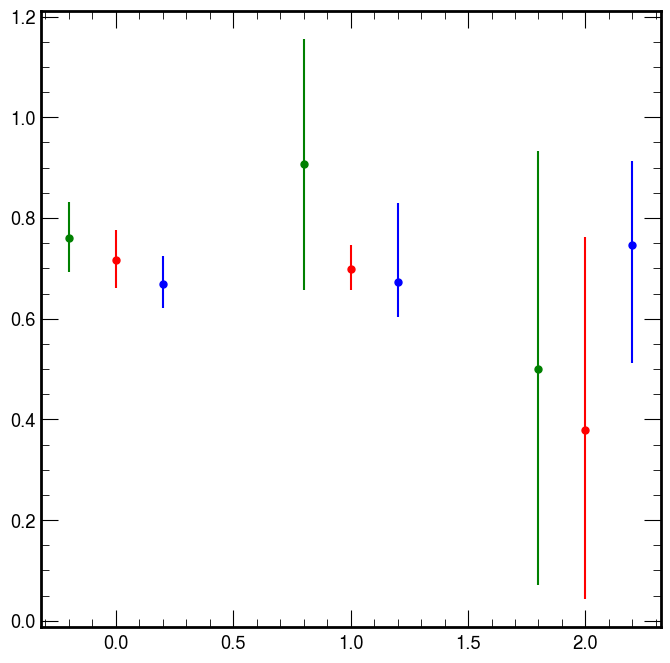

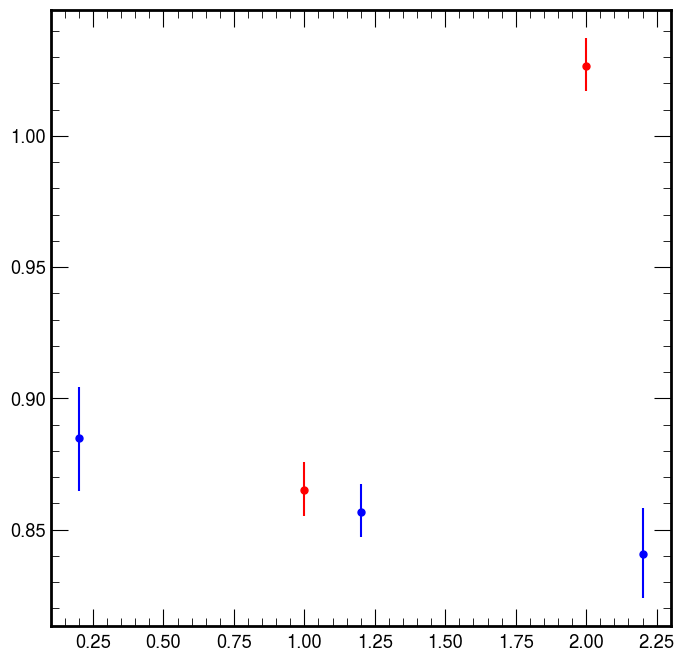

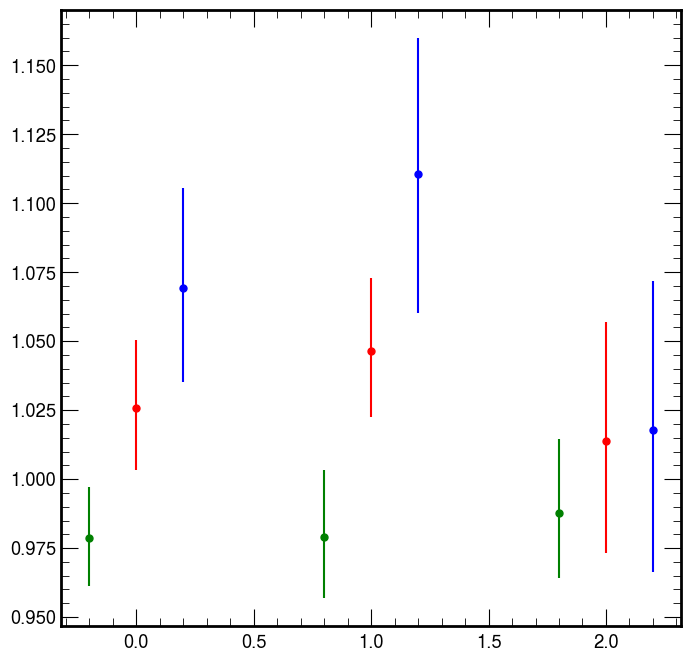

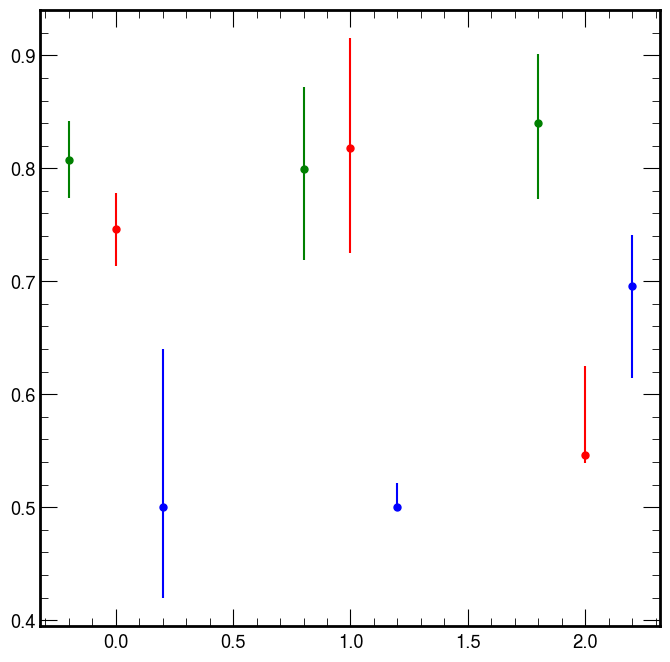

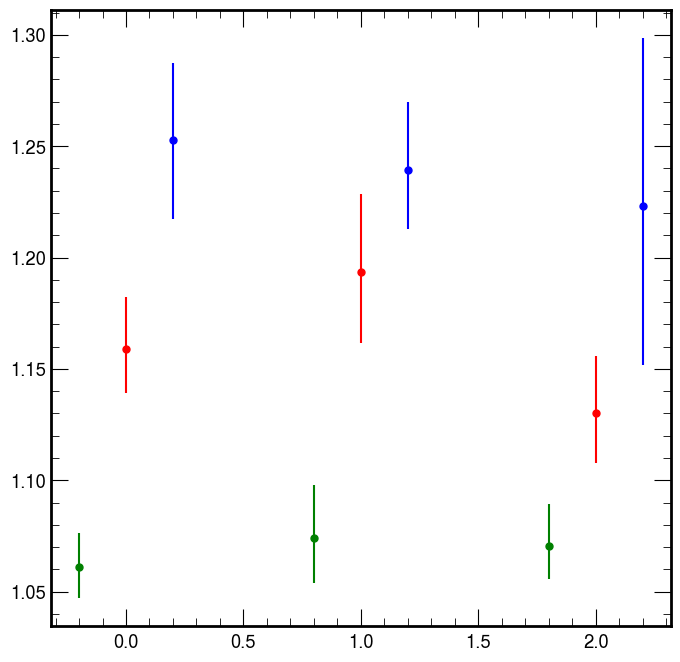

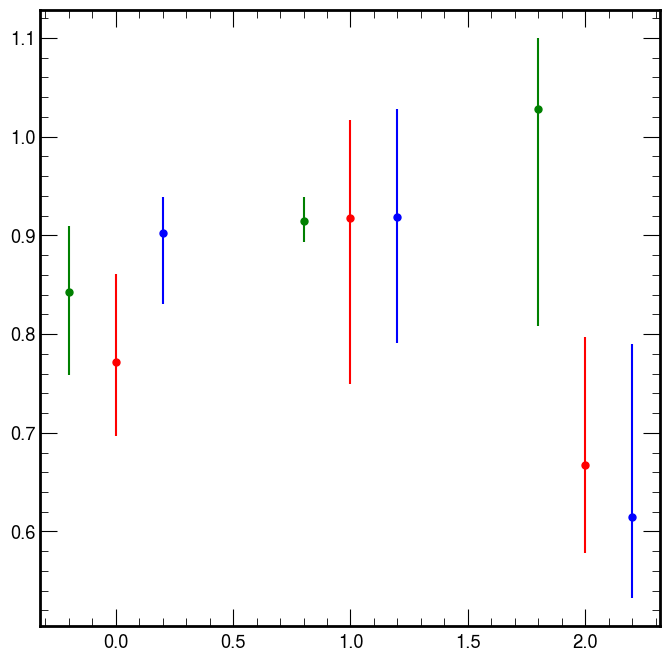

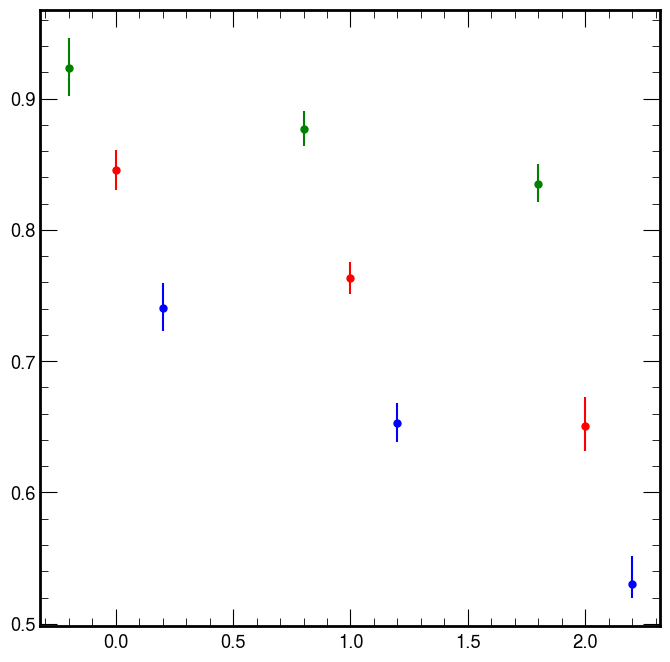

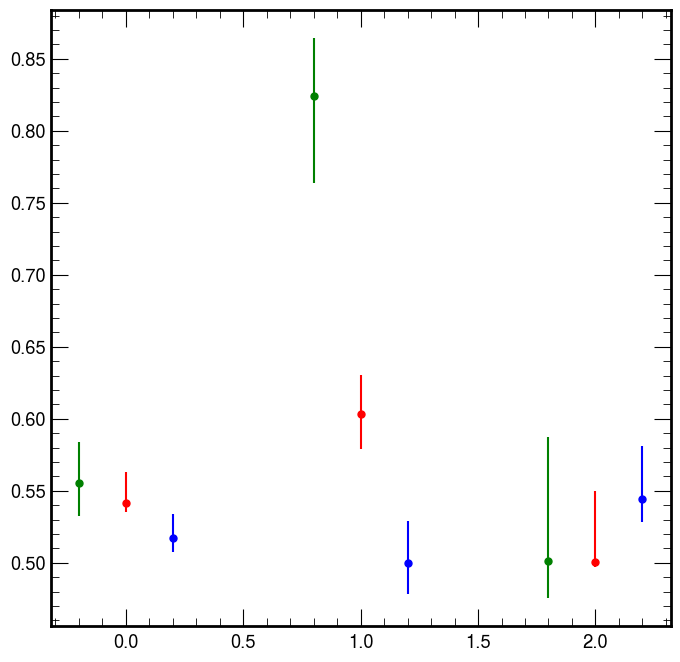

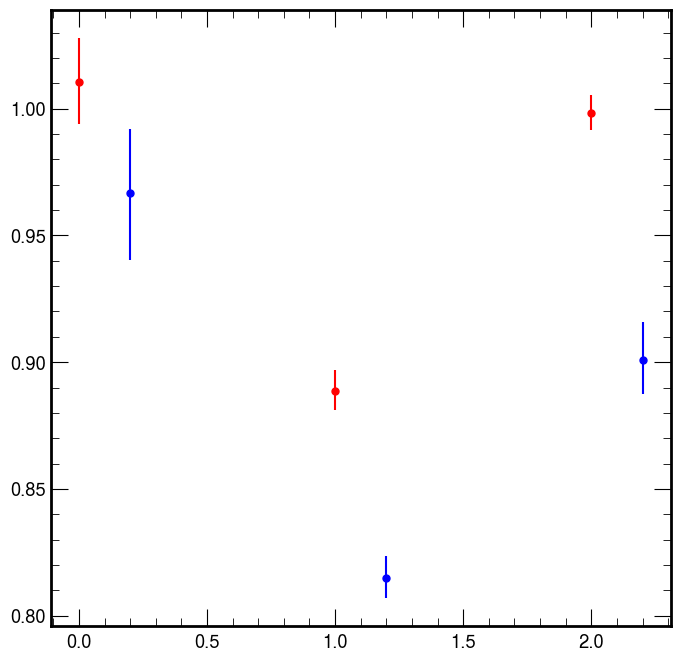

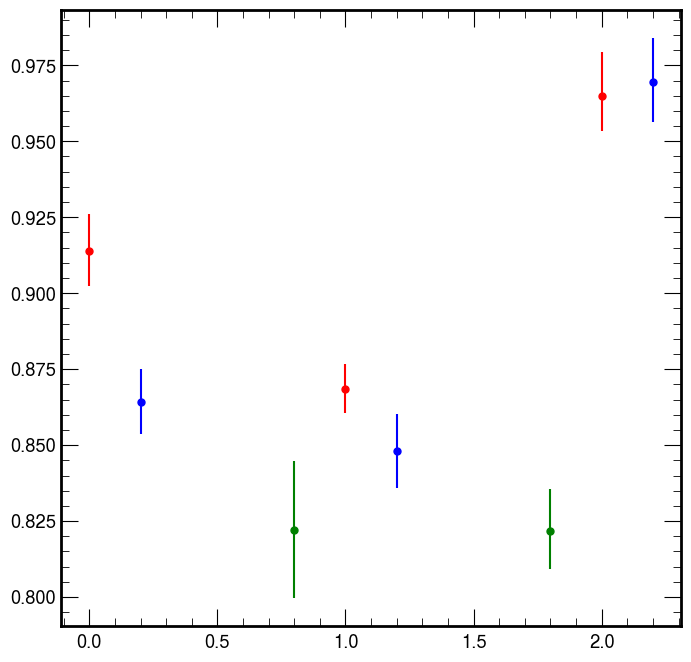

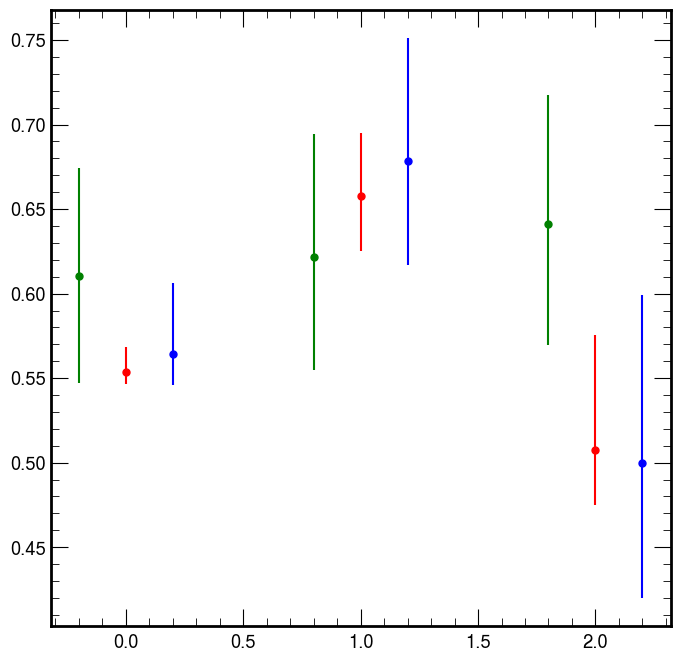

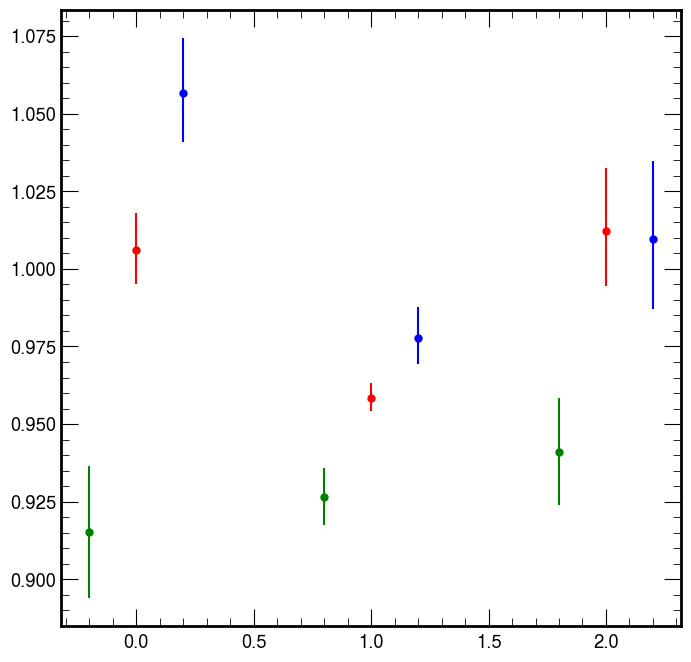

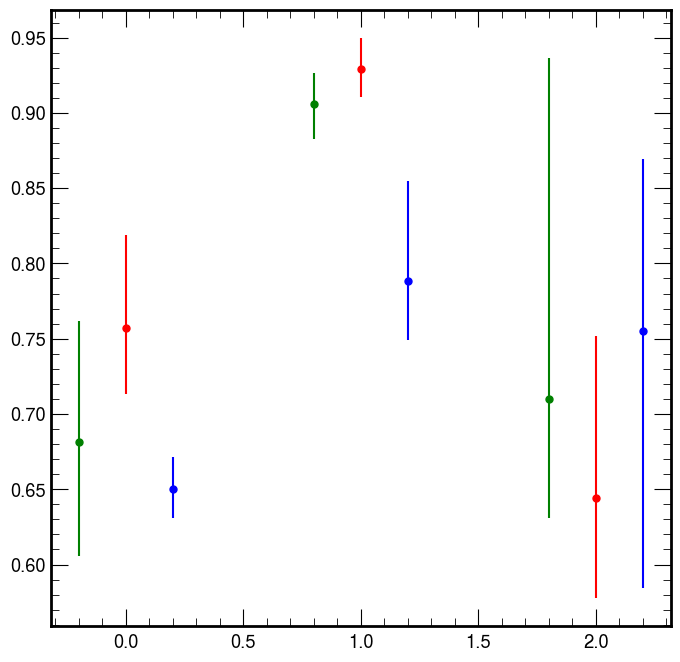

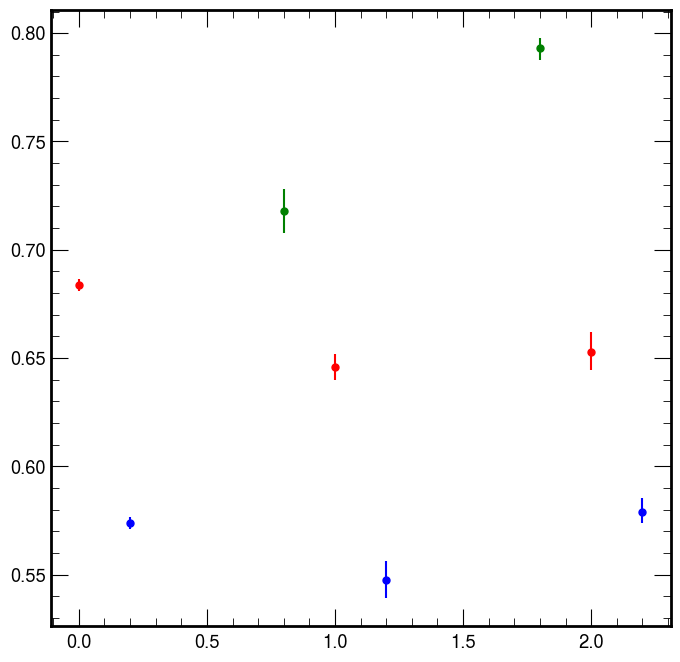

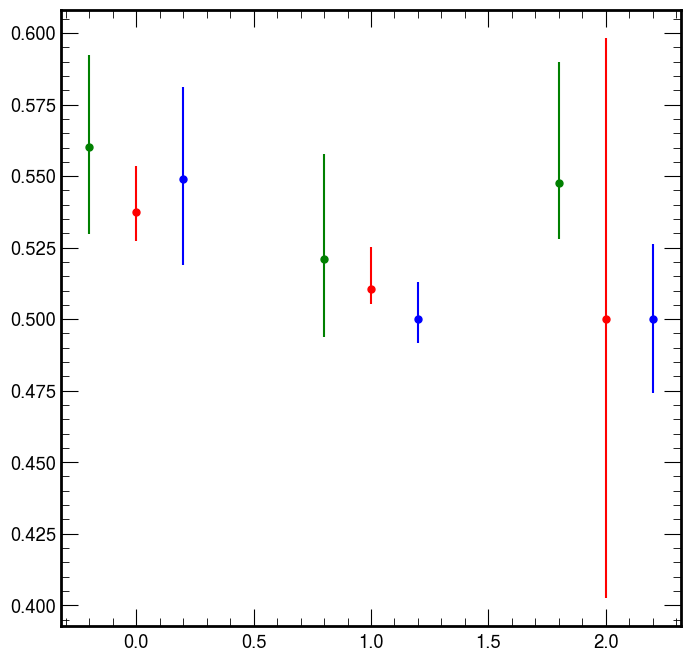

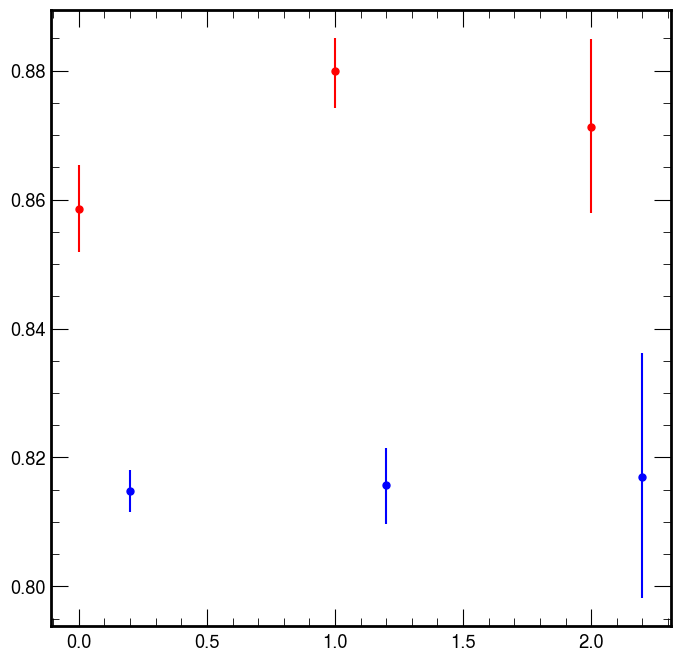

In [56]:
def get_unc(d, tau21_uncertainty="tau21_uncertainty_max"):
    ignore = ["tau21_uncertainty"]
    up = sum([ d[syst]["high"]**2 for syst in d.keys() if not syst in ignore ])
    down = sum([ d[syst]["low"]**2 for syst in d.keys() if not syst in ignore ])
    return down, up

colors = ["green", "red", "blue"]

offset = {
    "L" : -0.2,
    "M" : 0.0,
    "H" : 0.2,
}


for year in folders.keys():
    for tagger in AK8Taggers:
        fig, ax = plt.subplots(1, 1, figsize=[8,8])
        x = np.arange(3)
        for j, wp in enumerate(["L", "M", "H"]):
            if not wp in final_results[year][tagger][pt].keys():
                continue
            indices = []
            off = []
            y = []
            yerr_up = []
            yerr_down = []
            for i, pt in enumerate(["450to500", "500to600", "600toInf"]):
                if not wp in final_results[year][tagger][pt].keys():
                    continue
                indices.append(i)
                off.append(offset[wp])
                d = final_results[year][tagger][pt][wp]
                sf = d["all"]["central"]
                y.append(sf)
                down, up = get_unc(d)
                yerr_down.append(down)
                yerr_up.append(up)
            ax.errorbar(x[np.array(indices)] + off, y, yerr=(yerr_down, yerr_up), color=colors[j],
                        linestyle='', marker='o', markersize=5, label=wp)